<a href="https://colab.research.google.com/github/maheshisewwandisamaraweera/image-authentication-project/blob/maheshi/notebooks/data_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install opencv-python-headless Pillow numpy matplotlib tensorflow

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow as tf

In [3]:
print("📁 Upload image")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image_bytes = uploaded[filename]

nparr = np.frombuffer(image_bytes, np.uint8)
img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

📁 Upload image


Saving Fighting2-001.png to Fighting2-001.png


In [4]:
def enhance_image(img):

    gaussian = cv2.GaussianBlur(img, (0, 0), 3)
    unsharp = cv2.addWeighted(img, 1.8, gaussian, -0.8, 0)

    kernel = np.array([
        [-1,-1,-1],
        [-1, 9,-1],
        [-1,-1,-1]
    ])
    sharp = cv2.filter2D(unsharp, -1, kernel)

    lab = cv2.cvtColor(sharp, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(2.5, (8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return enhanced

enhanced_img = enhance_image(img)
enhanced_rgb = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB)

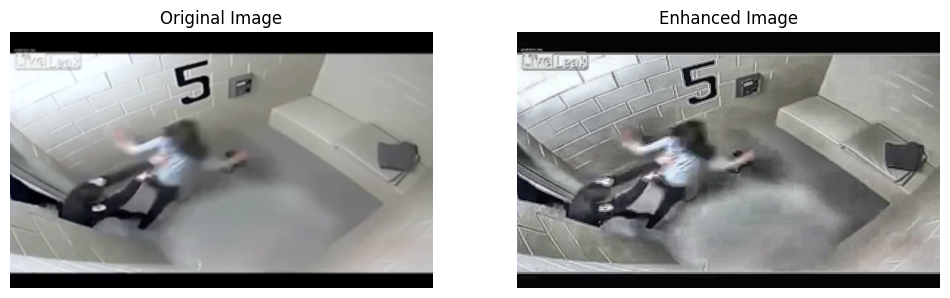

In [5]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_rgb)
plt.title("Enhanced Image")
plt.axis("off")

plt.show()

In [6]:
def prepare_for_model(img):
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

In [ ]:
cd /content/drive/MyDrive/image-authentication-project

/content/drive/MyDrive/image-authentication-project


In [ ]:
!pip install tensorflow opencv-python


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python train.py

2026-05-07 09:31:21.348352: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Traceback (most recent call last):
  File "/content/drive/MyDrive/image-authentication-project/train.py", line 20, in <module>
    for file in os.listdir(folder):
                ^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'data/ai_generated'


In [ ]:
!ls


data  model.h5	notebooks  README.md  src  train.py


In [9]:
import tensorflow as tf

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

model_path = "/content/drive/MyDrive/image-authentication-project/model.h5"
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded successfully


In [ ]:
from google.colab import files

files.download('model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import cv2

def prepare_for_model(img):
    img = cv2.resize(img, (224, 224))   # must match your training input size
    img = img / 255.0                   # normalize
    img = np.expand_dims(img, axis=0)   # add batch dimension
    return img

In [ ]:
!python train.py


2026-05-07 09:35:00.310648: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Dataset shape: (13, 224, 224, 3)
2026-05-07 09:35:10.120834: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778146510.122257    6943 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
2026-05-07 09:35:27.261804: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f2d180039c0 initialized for platform CUDA (this does not 

In [5]:
from google.colab import files
import cv2
import numpy as np

uploaded = files.upload()

filename = list(uploaded.keys())[0]
image_bytes = uploaded[filename]

nparr = np.frombuffer(image_bytes, np.uint8)
img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

Saving Fighting2-001.png to Fighting2-001.png


In [6]:
def enhance_image(img):
    gaussian = cv2.GaussianBlur(img, (0, 0), 3)
    unsharp = cv2.addWeighted(img, 1.8, gaussian, -0.8, 0)

    kernel = np.array([
        [-1,-1,-1],
        [-1, 9,-1],
        [-1,-1,-1]
    ])
    sharp = cv2.filter2D(unsharp, -1, kernel)

    return sharp

In [7]:
enhanced_img = enhance_image(img)

In [10]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive

In [11]:
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
model_path = "/content/drive/MyDrive/image-authentication-project/models/model.h5"
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

Model loaded successfully


In [13]:
class_names = ["Actual", "Edited", "AI Generated"]

In [14]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)

Saving Fighting2-001.png to Fighting2-001 (1).png


In [15]:
def preprocess(img):
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

In [16]:
def enhance(img):
    blur = cv2.GaussianBlur(img, (0,0), 3)
    sharp = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    return sharp

image = enhance(image)

In [17]:
input_img = preprocess(image)

prediction = model.predict(input_img)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [18]:
class_id = np.argmax(prediction)
confidence = prediction[class_id]

print("Prediction:", class_names[class_id])
print("Confidence:", confidence)

Prediction: Edited
Confidence: 0.76252705


In [19]:
for i, score in enumerate(prediction):
    print(f"{class_names[i]}: {score*100:.2f}%")

Actual: 0.25%
Edited: 76.25%
AI Generated: 23.50%


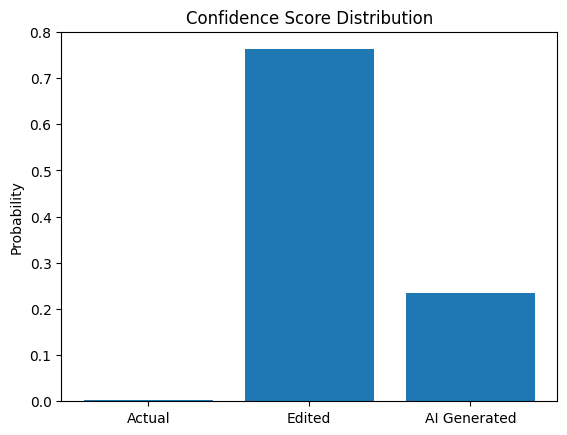

In [20]:
plt.bar(class_names, prediction)
plt.title("Confidence Score Distribution")
plt.ylabel("Probability")
plt.show()

In [21]:
class_names = ["Actual", "Edited", "AI Generated"]

class_colors = {
    "Actual": "green",
    "Edited": "orange",
    "AI Generated": "red"
}

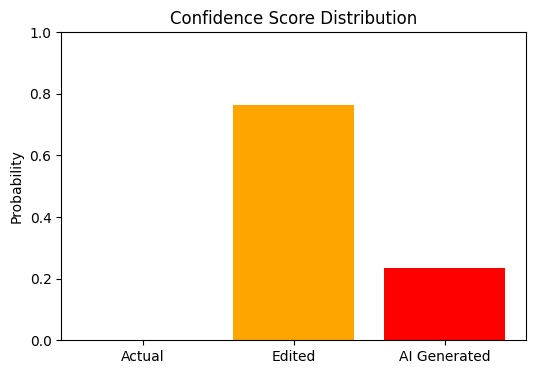

In [22]:
import matplotlib.pyplot as plt

colors = [class_colors[name] for name in class_names]

plt.figure(figsize=(6,4))
plt.bar(class_names, prediction, color=colors)

plt.title("Confidence Score Distribution")
plt.ylabel("Probability")

plt.ylim(0, 1)
plt.show()

In [23]:
predicted_class = class_names[class_id]

for i, name in enumerate(class_names):
    color = class_colors[name]
    score = prediction[i] * 100

    if i == class_id:
        print(f"👉 {name}: {score:.2f}% (PREDICTED)")
    else:
        print(f"{name}: {score:.2f}%")

Actual: 0.25%
👉 Edited: 76.25% (PREDICTED)
AI Generated: 23.50%


In [24]:
from IPython.display import display, HTML

html = ""
for i, name in enumerate(class_names):
    score = prediction[i] * 100
    color = class_colors[name]

    html += f"""
    <div style="margin:5px 0;">
        <b>{name}</b>
        <div style="background:#eee; width:300px; border-radius:10px;">
            <div style="width:{score}%; background:{color}; height:20px; border-radius:10px;"></div>
        </div>
        <small>{score:.2f}%</small>
    </div>
    """

display(HTML(html))